# Generation, oversampling, and traceability

Generate synthetic rows and inspect their trace records.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from mimic import MIMIC, GenerationPolicy, ResNetEncoder, MixedFeatureDecoder

rng = np.random.default_rng(2)

def make_spiral(label, n, phase, noise=0.12):
    theta = np.linspace(0.45, 4.8 * np.pi, n)
    radius = np.linspace(0.25, 4.0, n)
    x = radius * np.cos(theta + phase) + rng.normal(0, noise, n)
    y = radius * np.sin(theta + phase) + rng.normal(0, noise, n)
    return pd.DataFrame({"x": x, "y": y, "label": label})

major = make_spiral("majority", 180, phase=0.0)
minor_full = make_spiral("minority", 180, phase=np.pi)
minor = minor_full.sample(n=45, random_state=2).sort_index().reset_index(drop=True)

df = pd.concat([major, minor], ignore_index=True)
df["id"] = np.arange(len(df))

display(df["label"].value_counts().rename_axis("label").to_frame("count").style.set_caption("Original class balance"))
display(df.head(8).style.set_caption("Original two-spiral training rows"))


In [ ]:
mimic = MIMIC(
    ignore_columns=["id"],
    regression_columns=["x", "y"],
    classification_columns=["label"],
    encoder=ResNetEncoder(embedding_dim=2, hidden_dim=32, n_layers=4, dropout=0.05, max_epochs=40, patience=6, batch_size=64, random_state=2),
    decoder=MixedFeatureDecoder.linear(),
    policy=GenerationPolicy(method="displacement", neighbour_mode="mutual", n_neighbors=3, lambda_range=(0.01, 0.3)),
    n_bootstrap=1,
    random_state=2,
)
mimic.fit(df)
synthetic, trace = mimic.sample(12, return_trace=True)

display(synthetic.head(8).style.set_caption("Displacement-generated sample rows"))
display(trace.head(8).style.set_caption("Displacement generation trace"))


In [3]:
minority_needed = df["label"].value_counts()["majority"] - df["label"].value_counts()["minority"]
generated, generation_trace = mimic.sample(minority_needed * 10, return_trace=True)
minority_mask = generated["label"].eq("minority")
minority_synthetic = generated.loc[minority_mask].head(minority_needed).reset_index(drop=True)
minority_trace = generation_trace.loc[minority_mask.to_numpy()].head(minority_needed).reset_index(drop=True)
balanced = pd.concat([df.drop(columns=["id"]), minority_synthetic], ignore_index=True)

display(balanced["label"].value_counts().rename_axis("label").to_frame("count").style.set_caption("Class balance after displacement oversampling"))
display(minority_synthetic.head(8).style.set_caption("Synthetic minority spiral rows"))
display(minority_trace.head(8).style.set_caption("Oversampling trace for retained minority rows"))


,count
label,
majority,180
minority,100


,x,y,label
0,-0.339938,-0.436001,minority
1,-0.030381,0.573177,minority
2,-0.416064,-0.310603,minority
3,0.097159,0.721792,minority
4,-0.350333,-0.418378,minority
5,-0.353224,-0.413706,minority
6,-0.401645,-0.335680,minority
7,-0.336202,-0.442081,minority


,sample_index,method,anchor_index,displacement_from_index,displacement_to_index,lambda,neighbour_mode,restriction,decoder,random_state
0,7,displacement,217,219,216,0.123571,mutual,basic,LinearMixedFeatureDecoder,2
1,9,displacement,114,113,115,0.234914,mutual,basic,LinearMixedFeatureDecoder,2
2,10,displacement,219,218,219,0.278023,mutual,basic,LinearMixedFeatureDecoder,2
3,15,displacement,116,115,116,0.182099,mutual,basic,LinearMixedFeatureDecoder,2
4,33,displacement,217,218,219,0.209818,mutual,basic,LinearMixedFeatureDecoder,2
5,64,displacement,217,216,219,0.080951,mutual,basic,LinearMixedFeatureDecoder,2
6,72,displacement,218,216,217,0.085244,mutual,basic,LinearMixedFeatureDecoder,2
7,132,displacement,217,218,216,0.219141,mutual,basic,LinearMixedFeatureDecoder,2


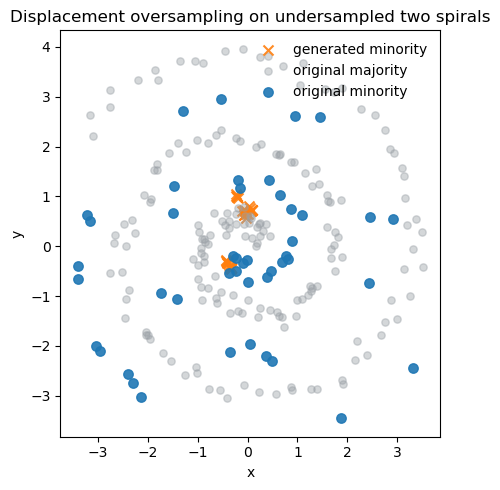

In [4]:
plot_df = pd.concat(
    [
        df.drop(columns=["id"]).assign(source="original"),
        minority_synthetic.assign(source="generated"),
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(6, 5))
for (source, label), part in plot_df.groupby(["source", "label"]):
    if source == "original" and label == "majority":
        color, marker, alpha, size = "#9aa0a6", "o", 0.42, 28
    elif source == "original" and label == "minority":
        color, marker, alpha, size = "#1f77b4", "o", 0.9, 46
    else:
        color, marker, alpha, size = "#ff7f0e", "x", 0.9, 52
    ax.scatter(part["x"], part["y"], label=f"{source} {label}", color=color, marker=marker, alpha=alpha, s=size)
ax.set_title("Displacement oversampling on undersampled two spirals")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="box")
ax.legend(frameon=False)
fig.tight_layout()
